# 1.Introduccion






En un mercado cada vez más competitivo, el crecimiento de un emprendimiento no depende únicamente de la calidad del producto. Factores como el precio, la percepción del cliente, el nivel de ingresos del consumidor y las estrategias de marketing se han convertido en variables clave para entender el comportamiento de compra.

En este análisis, se utilizará un dataset relacionado con Kelly Cupcakes, un emprendimiento dedicado a la venta de cupcakes artesanales, con el fin de explorar patrones de consumo, identificar relaciones entre variables y extraer hallazgos que permitan comprender mejor qué elementos influyen en la disposición de los clientes a pagar por el producto.

Más allá de una descripción básica de los datos, este estudio busca aplicar herramientas de análisis exploratorio y estadístico para evaluar tendencias, detectar variables relevantes y generar conclusiones útiles para la toma de decisiones comerciales y estratégicas del negocio.

A partir de este enfoque, el análisis pretende responder una pregunta central:

¿Qué factores influyen en el precio que los clientes están dispuestos a pagar por los productos de Kelly Cupcakes según el dataset analizado?

In [ ]:
!pip install category_encoders shap yellowbrick

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import shap
import category_encoders as ca

from scipy import stats
from scipy.stats import skew, boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.regressor import ResidualsPlot, PredictionError
from category_encoders import TargetEncoder
from ipywidgets import interact
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")


2.Dataset

In [ ]:
file_id = '1FYphMecW3-PpuAcqcwJKw0ApYSxSegsg' #Solo modificar esta línea
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_excel(url)
df

,Edad,Número de personas que viven con el encuestado,Salario que gana,Sector en el que vive,Gasto,Sexo,Calificación que le daría al producto,Precio de compra
0,31,1,1265000,Rural,86569,M,58.535262,50498
1,36,2,961100,Urbano,77080,M,79.985951,45228
2,27,0,1053500,Urbano,80066,F,67.579597,51603
3,32,1,651900,Urbano,77144,M,86.942994,39790
4,36,1,2412100,Rural,84046,F,73.159599,75266
...,...,...,...,...,...,...,...,...
995,35,1,1841200,Rural,89863,M,54.595825,68524
996,36,1,1242100,Urbano,82596,M,69.247759,51903
997,34,1,826300,Urbano,64939,M,66.002380,48961
998,24,1,728100,Urbano,68664,M,56.612403,45528


# 2. PIPELINE / ANÁLISIS EXPLORATORIO DE DATOS (EDA) + PREPROCESAMIENTO DE DATOS



Algunas abreviaciones dentro del dataset:

Product type (Tipo de producto)

CC = Cupcake clásico
CP = Cupcake premium
CG = Cupcake con glaseado
CE = Cupcake especial
TR = Tarjeta regalo

Flavor (Sabor)

FR = Frutos rojos
AM = Amaretto
FS = Frutos secos
AR = Arequipe
AL = Almendras

Customer income level (Nivel de ingreso del cliente)

L = Bajo
M = Medio
H = Alto

Payment willingness (Disposición de pago)

LP = Bajo precio dispuesto a pagar
MP = Precio medio dispuesto a pagar
HP = Alto precio dispuesto a pagar

Product rating (Calificación del producto)

1 - 5 = Escala de satisfacción o percepción del cliente sobre el producto

Purchase frequency (Frecuencia de compra)

O = Ocasional
F = Frecuente
R = Recurrente

Sales channel (Canal de venta)

FB = Facebook
IG = Instagram
WA = WhatsApp

Marketing response (Respuesta a estrategia de marketing)

P = Promoción
D = Descuento
PV = Publicidad visual
RS = Redes sociales

Customer preference (Preferencia del cliente)

PR = Presentación
CA = Calidad
SA = Sabor
PRC = Precio



In [ ]:
df.head(10)

,Edad,Número de personas que viven con el encuestado,Salario que gana,Sector en el que vive,Gasto,Sexo,Calificación que le daría al producto,Precio de compra
0,31,1,1265000,Rural,86569,M,58.535262,50498
1,36,2,961100,Urbano,77080,M,79.985951,45228
2,27,0,1053500,Urbano,80066,F,67.579597,51603
3,32,1,651900,Urbano,77144,M,86.942994,39790
4,36,1,2412100,Rural,84046,F,73.159599,75266
5,38,2,943300,Urbano,68847,M,69.268386,51981
6,30,1,1704700,Rural,89555,M,70.043988,61113
7,25,2,1683700,Rural,62697,M,74.808623,60020
8,23,1,2571200,Urbano,69202,M,63.157843,84723
9,27,2,900300,Urbano,87450,M,73.592365,48789


In [ ]:
df.sample(10)

,Edad,Número de personas que viven con el encuestado,Salario que gana,Sector en el que vive,Gasto,Sexo,Calificación que le daría al producto,Precio de compra
629,33,0,1454100,Urbano,64572,M,69.483255,60348
448,33,2,1694200,Urbano,81732,F,61.168020,67880
530,35,2,738900,Urbano,81678,F,85.075902,38333
455,37,3,1220200,Rural,89806,M,73.077722,57380
687,24,1,1166100,Urbano,70327,F,59.040613,50963
762,32,4,2982600,Rural,61371,M,67.774729,93663
949,34,2,1265800,Urbano,68942,F,81.481995,51907
692,25,4,1720600,Rural,75793,F,87.740211,67889
923,27,1,1385500,Rural,74597,M,74.754282,55895
113,30,3,2039000,Rural,71858,F,81.008406,68939


In [ ]:
df.tail(10)

,Edad,Número de personas que viven con el encuestado,Salario que gana,Sector en el que vive,Gasto,Sexo,Calificación que le daría al producto,Precio de compra
990,31,3,1093400,Rural,65184,F,76.949455,49269
991,29,3,935200,Rural,86279,M,68.536448,44776
992,26,2,2031400,Urbano,60184,M,67.537666,67024
993,25,2,495500,Urbano,81830,M,54.510506,44122
994,29,2,752700,Urbano,85161,M,82.172689,40546
995,35,1,1841200,Rural,89863,M,54.595825,68524
996,36,1,1242100,Urbano,82596,M,69.247759,51903
997,34,1,826300,Urbano,64939,M,66.002380,48961
998,24,1,728100,Urbano,68664,M,56.612403,45528
999,27,2,2336000,Urbano,71128,F,55.404237,76817


In [ ]:
df.iloc[4:100]

,Edad,Número de personas que viven con el encuestado,Salario que gana,Sector en el que vive,Gasto,Sexo,Calificación que le daría al producto,Precio de compra
4,36,1,2412100,Rural,84046,F,73.159599,75266
5,38,2,943300,Urbano,68847,M,69.268386,51981
6,30,1,1704700,Rural,89555,M,70.043988,61113
7,25,2,1683700,Rural,62697,M,74.808623,60020
8,23,1,2571200,Urbano,69202,M,63.157843,84723
...,...,...,...,...,...,...,...,...
95,33,2,1218500,Urbano,70794,M,85.653481,57632
96,33,2,1036800,Rural,74388,M,69.273041,48397
97,32,4,1347600,Urbano,87814,F,73.177341,55874
98,30,2,1749800,Rural,81348,F,58.486342,60057


## codificacion

In [ ]:
# Re-cargamos el dataframe para asegurar que 'df' esté definido
file_id = '1FYphMecW3-PpuAcqcwJKw0ApYSxSegsg'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_excel(url)

# Eliminar columnas vacías si las hay
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Codificación binaria para Sexo: M=0, F=1
df['Sexo_Binario'] = df['Sexo'].map({'M': 0, 'F': 1})

# Codificación binaria para Sector: Rural=0, Urbano=1
df['Sector_Binario'] = df['Sector en el que vive'].map({'Rural': 0, 'Urbano': 1})

# Verificamos los cambios
display(df[['Sexo', 'Sexo_Binario', 'Sector en el que vive', 'Sector_Binario']])

,Sexo,Sexo_Binario,Sector en el que vive,Sector_Binario
0,M,0,Rural,0
1,M,0,Urbano,1
2,F,1,Urbano,1
3,M,0,Urbano,1
4,F,1,Rural,0
...,...,...,...,...
995,M,0,Rural,0
996,M,0,Urbano,1
997,M,0,Urbano,1
998,M,0,Urbano,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Edad                                            1000 non-null   int64  
 1   Número de personas que viven con el encuestado  1000 non-null   int64  
 2   Salario que gana                                1000 non-null   int64  
 3   Sector en el que vive                           1000 non-null   object 
 4   Gasto                                           1000 non-null   int64  
 5   Sexo                                            1000 non-null   object 
 6   Calificación que le daría al producto           1000 non-null   float64
 7   Precio de compra                                1000 non-null   int64  
 8   Sexo_Binario                                    1000 non-null   int64  
 9   Sector_Binario                            

# Features numéricas:
Precio dispuesto a pagar, calificación del producto, edad del cliente, ingreso mensual, frecuencia de compra y cantidad de productos comprados son variables numéricas dentro del dataset.
# Features categóricas:
Las columnas tipo de producto, sabor, canal de venta, nivel de ingreso, respuesta a marketing y preferencia del cliente son categóricas.

In [ ]:
missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"Cuantos Nulos": missing_count, "Porcentaje": missing_percentage})
missing_df

,Cuantos Nulos,Porcentaje
Edad,0,0.0
Número de personas que viven con el encuestado,0,0.0
Salario que gana,0,0.0
Sector en el que vive,0,0.0
Gasto,0,0.0
Sexo,0,0.0
Calificación que le daría al producto,0,0.0
Precio de compra,0,0.0
Sexo_Binario,0,0.0
Sector_Binario,0,0.0


## Análisis de datos duplicados

In [ ]:

duplicates_all = df[df.duplicated(keep=False)]

print(f"Total de filas que pertenecen a duplicados exactos: {len(duplicates_all)}")


duplicates_real = df[df.duplicated()]

print(f"Total de duplicados reales: {len(duplicates_real)}")



Total de filas que pertenecen a duplicados exactos: 0
Total de duplicados reales: 0


## Estadistica Descriptiva

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,1000.0,3.099800e+01,4.366585,17.000000,28.000000,3.100000e+01,3.400000e+01,4.500000e+01
Número de personas que viven con el encuestado,1000.0,1.996000e+00,0.885872,0.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00
Salario que gana,1000.0,1.368670e+06,584209.070099,301400.000000,915725.000000,1.275600e+06,1.744200e+06,2.982600e+06
Gasto,1000.0,7.504373e+04,8841.994483,60009.000000,67425.750000,7.485500e+04,8.282600e+04,8.999400e+04
Calificación que le daría al producto,1000.0,6.997636e+01,8.611233,41.128587,64.088775,6.995225e+01,7.619932e+01,9.907441e+01
Precio de compra,1000.0,5.705090e+04,12935.116943,31369.000000,47194.500000,5.559550e+04,6.530100e+04,9.391300e+04
Sexo_Binario,1000.0,5.220000e-01,0.499766,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
Sector_Binario,1000.0,4.770000e-01,0.499721,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000e+00



## Interpretación:

1. **Edad:**
   La mediana es **31 años** y el promedio **30.99**, por lo que la distribución es bastante equilibrada. La mayoría de los encuestados está entre **28 y 34 años**.

2. **Número de personas que viven con el encuestado:**
   La mediana es **2** y el promedio **1.996**, lo que muestra hogares pequeños o medianos.

3. **Salario que gana:**
   El promedio (**1,368,670.3**) es mayor que la mediana (**1,275,600**), lo que sugiere algunos salarios altos que elevan la media. Es una variable con buena dispersión.

4. **Gasto:**
   La media (**75,043.73**) y la mediana (**74,855**) son muy cercanas, así que el gasto tiene un comportamiento bastante estable.

5. **Calificación que le daría al producto:**
   El promedio (**69.98**) y la mediana (**69.95**) son casi iguales, lo que indica una percepción del producto bastante equilibrada.

6. **Precio de compra:**
   Tiene una media de **57,050.9** y una mediana de **55,595.5**, con una variación importante entre el mínimo y el máximo. Esto lo hace clave para el análisis.

## Nota técnica:

En general, varias variables tienen **media y mediana muy cercanas**, lo que sugiere distribuciones relativamente simétricas. En **salario** y **precio de compra** sí se nota más dispersión.


### Matriz de correlacion

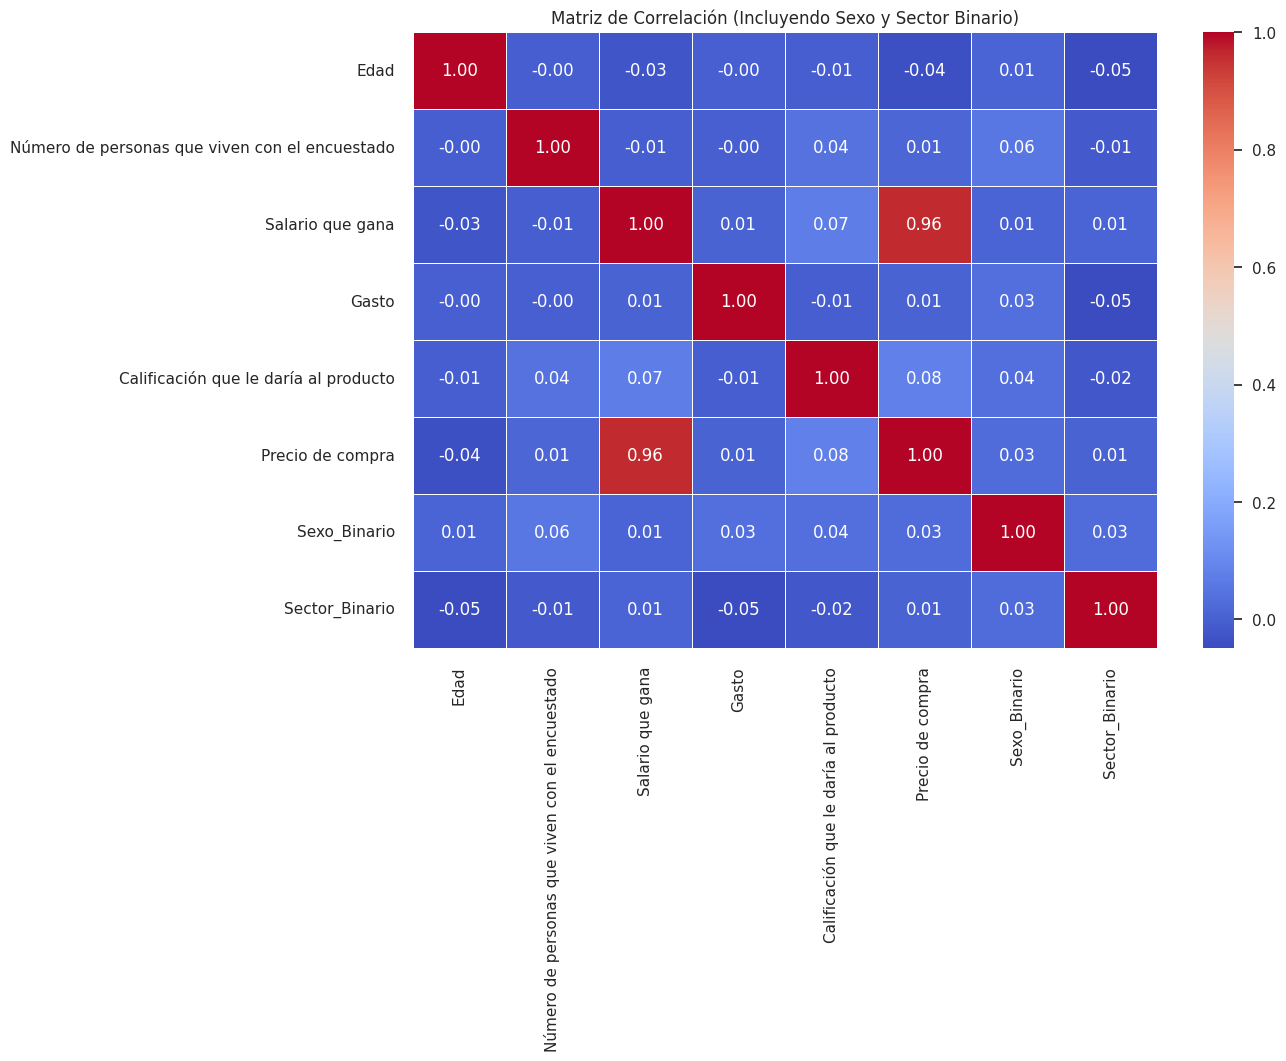

In [ ]:

# Seleccionamos las columnas numéricas (incluye las binarias recién creadas)
df_numeric = df.select_dtypes(include=[np.number])

# Generar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación (Incluyendo Sexo y Sector Binario)')
plt.show()

El análisis de la matriz de correlación evidencia que la única relación significativa dentro del modelo es la existente entre el salario y el precio de compra, con un coeficiente de 0.96, lo que indica una correlación positiva muy fuerte; esto sugiere que a medida que aumenta el ingreso de los individuos, también incrementa su disposición a pagar por el producto. En contraste, variables como la edad, el número de personas en el hogar, el gasto, la calificación del producto, así como las variables categóricas de sexo y sector, presentan coeficientes cercanos a cero, lo que indica relaciones débiles o prácticamente inexistentes. En particular, la calificación del producto no muestra asociación relevante con ninguna de las variables analizadas, lo que sugiere que la percepción del mismo podría depender de factores no incluidos en el modelo. En conjunto, los resultados permiten concluir que el ingreso es el principal determinante del comportamiento de compra en la muestra estudiada, mientras que las demás variables no presentan una influencia significativa desde el punto de vista de la correlación lineal.

### Visualizacion de datos

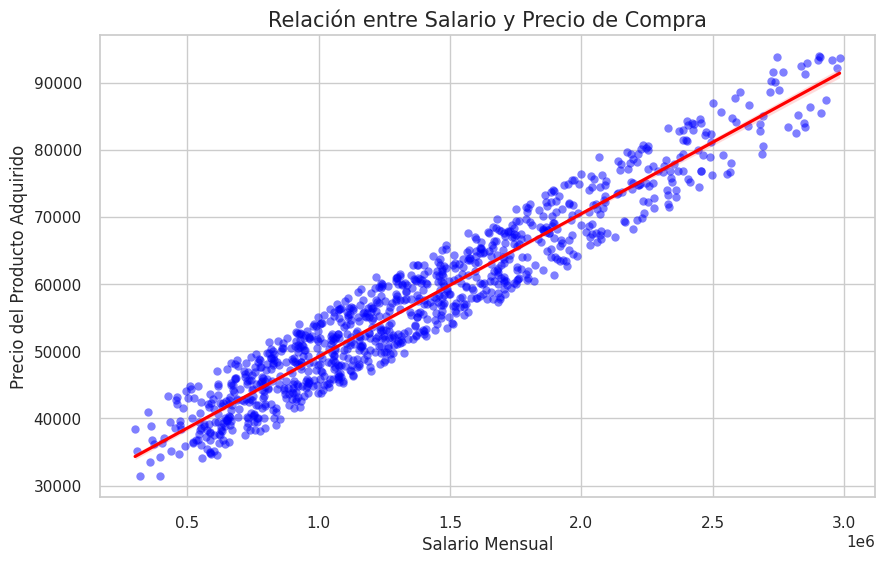

In [ ]:

# Configuramos el estilo
sns.set_style("whitegrid")

# Creamos el gráfico de dispersión con línea de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x='Salario que gana', y='Precio de compra', data=df,
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'})

# Personalización de títulos (ajustado a tu proyecto)
plt.title('Relación entre Salario y Precio de Compra', fontsize=15)
plt.xlabel('Salario Mensual', fontsize=12)
plt.ylabel('Precio del Producto Adquirido', fontsize=12)

plt.show()

El gráfico de dispersión muestra una relación lineal positiva muy fuerte entre el salario mensual y el precio de compra del producto, evidenciada tanto por la alineación ascendente de los puntos como por la pendiente creciente de la recta de regresión. A medida que aumenta el ingreso, el precio que los consumidores están dispuestos a pagar también se incrementa de forma consistente, lo que sugiere que el salario es un predictor clave del comportamiento de compra. La dispersión de los datos alrededor de la línea es relativamente baja, indicando un buen ajuste del modelo lineal y una alta correlación entre las variables. En términos estadísticos, esto respalda la existencia de una relación directa y significativa, donde el ingreso explica en gran medida la variabilidad en el precio de adquisición del producto.

### Distribución de todas las variables



**Interpretación resumida de las variables**
Edad: Concentrada entre 28–34 años → cliente típico adulto joven.
**Personas en el hogar:** Predominan hogares de 2–3 personas → decisiones de compra compartidas.
**Salario:** Nivel medio con ligera variación → mercado con capacidad moderada de pago.
**Gasto:** Distribución amplia → clientes con comportamientos de consumo distintos (alta variabilidad).
**Calificación del producto: **Centrada en 65–75 → percepción aceptable, pero no sobresaliente.
**Precio de compra:** Mayor frecuencia entre 45k–65k → rango claro de disposición a pagar.
**Sexo:** Equilibrado → producto sin preferencia de género.
**Sector: **Equilibrado → aplicabilidad en diferentes contextos.

🧠 **Conclusión**

 Calificación que le daría al producto es el mejor ejemplo de una distribución mesocúrtica.

 Asimétrica Positiva: Salario que gana" y "Precio de compra

 Bimodal: Edad

 Uniforme (Rectangular): Gasto

 Distribución de Bernoulli (Degenerada/Binomial): Sexo_Binario y Sector_Binario


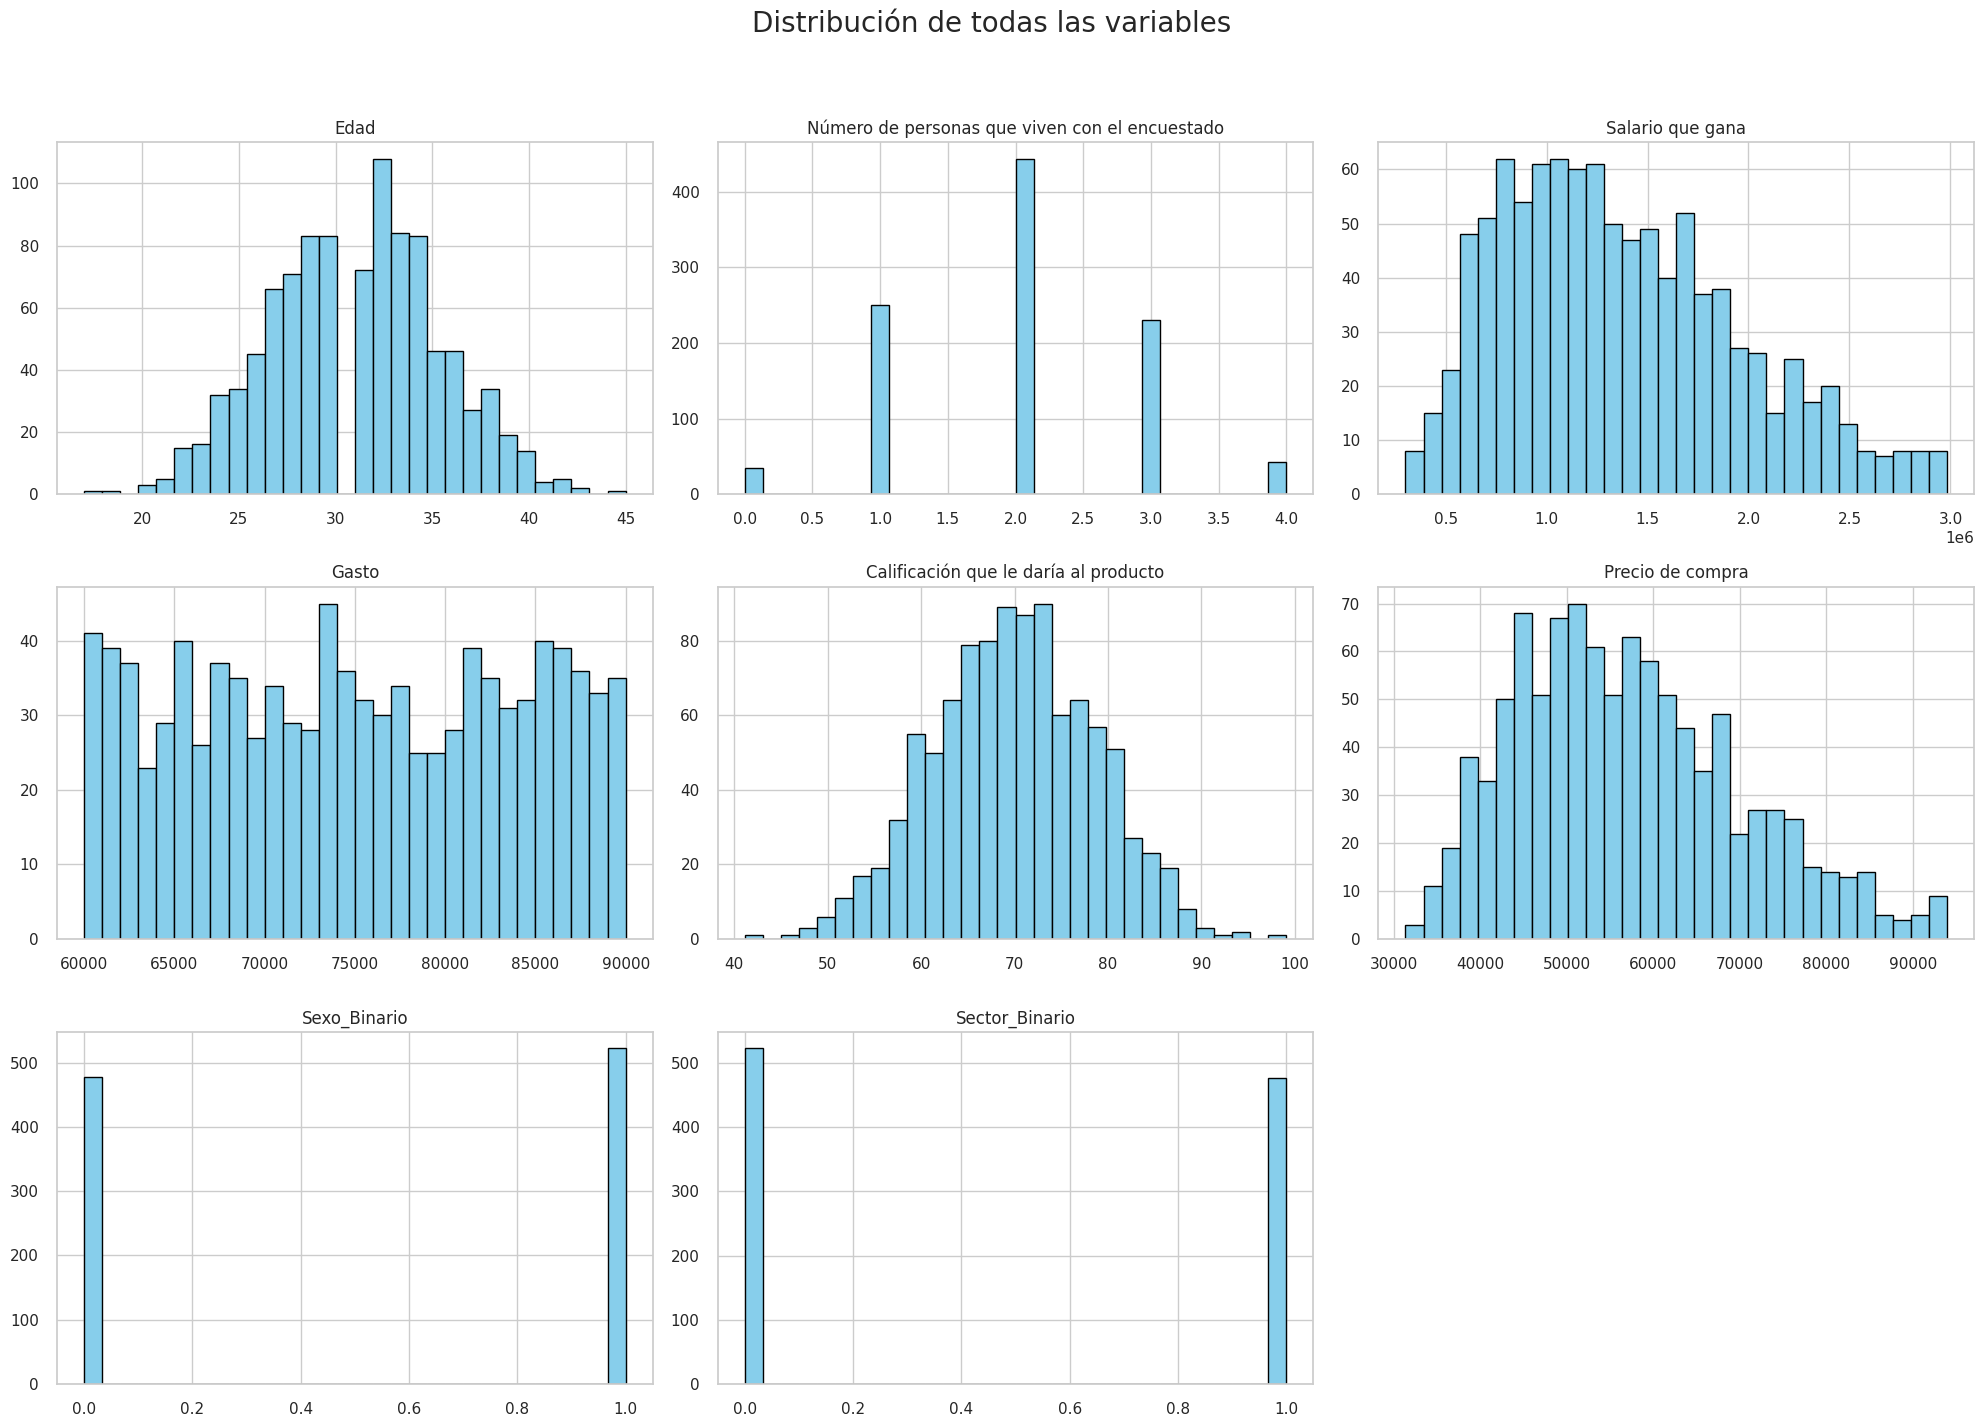

In [ ]:
# Visualización de la distribución de todas las variables numéricas
df.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribución de todas las variables', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Modelo K Means Clustering

### 1. Preparación de datos para Clustering

El gráfico de dispersión muestra la relación entre el Salario que gana y el Gasto, donde cada punto representa a un cliente. Los colores diferencian los segmentos encontrados, y los estilos marcan si el cliente vive en un sector Rural o Urbano.

Aquí tienes un resumen de las características promedio de cada segmento:

**Segmento 0 (257 personas): **Predominantemente hombres (Sexo_Binario 0.0) que viven en zonas rurales (Sector_Binario 0.0). Presentan salarios y gastos promedio, con una calificación de producto de 69.74.

**Segmento 1 (477 personas): **Este es el segmento más grande y se caracteriza por una distribución casi equitativa de hombres y mujeres (Sexo_Binario 0.54), residiendo mayoritariamente en zonas urbanas (Sector_Binario 1.0). Sus salarios y gastos también son promedio, y la calificación del producto es muy similar a la del Segmento 0.

**Segmento 2 (266 personas): **Principalmente mujeres (Sexo_Binario 1.0) de zonas rurales (Sector_Binario 0.0). Sus salarios y gastos son promedio, pero tienen una calificación ligeramente superior del producto (70.54).

En general, el clustering parece haber diferenciado los segmentos principalmente por el sexo y el sector de residencia, con salarios y gastos promedio bastante similares entre los grupos. La calificación del producto también muestra poca variación entre los segmentos.

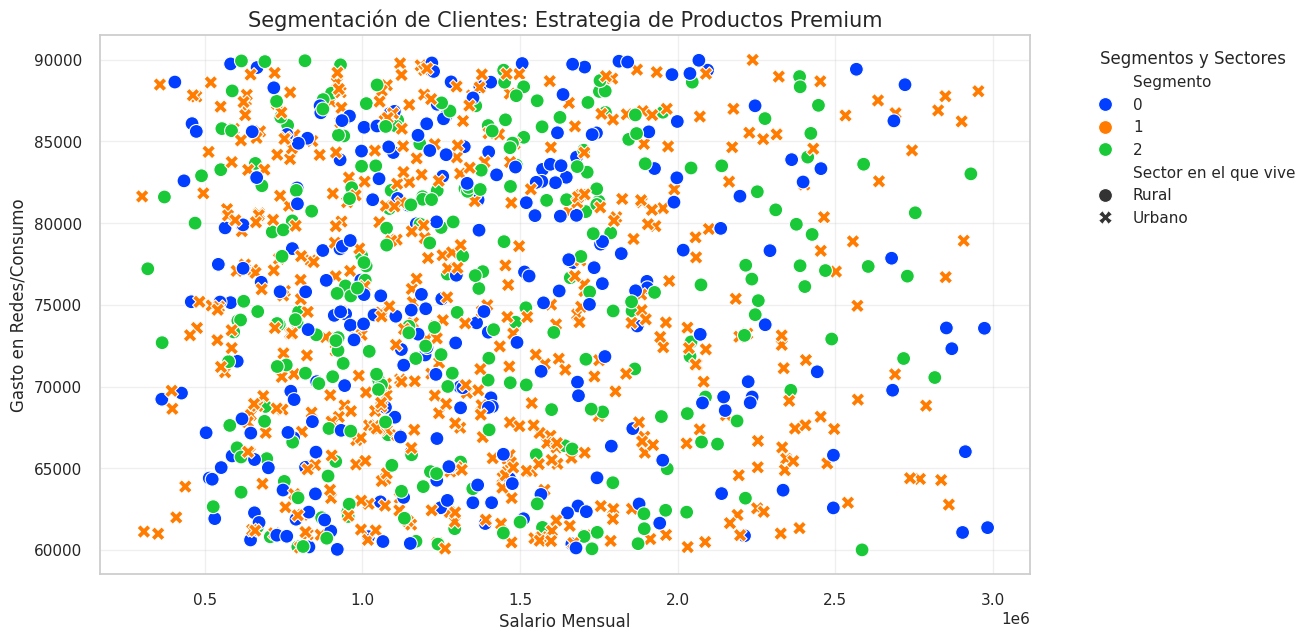

--- PERFIL PROMEDIO POR SEGMENTO ---
          Salario que gana     Gasto  Calificación que le daría al producto  \
Segmento                                                                      
0               1359200.00  75093.36                                  69.74   
1               1375050.73  74601.12                                  69.79   
2               1366378.57  75789.49                                  70.54   

          Sexo_Binario  Sector_Binario  
Segmento                                
0                 0.00             0.0  
1                 0.54             1.0  
2                 1.00             0.0  

El Segmento 0 tiene 257 personas.

El Segmento 1 tiene 477 personas.

El Segmento 2 tiene 266 personas.


In [ ]:
file_id = '1FYphMecW3-PpuAcqcwJKw0ApYSxSegsg' #Solo modificar esta línea
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_excel(url)

# Codificación rápida para las variables categóricas (para el clustering)
df['Sexo_Binario'] = df['Sexo'].map({'M': 0, 'F': 1})
df['Sector_Binario'] = df['Sector en el que vive'].map({'Rural': 0, 'Urbano': 1})

features = [
    'Salario que gana',
    'Gasto',
    'Calificación que le daría al producto',
    'Sexo_Binario',
    'Sector_Binario'
]

# Creamos una copia para no alterar el dataframe original
X = df[features].copy()

# 2. Escalamiento de datos (Indispensable para K-Means)
# Esto evita que el Salario (números grandes) domine sobre el Sexo (0 y 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar K-Means
# Usaremos 3 clusters: "Potencial Premium", "Intermedio" y "Bajo Perfil"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segmento'] = kmeans.fit_predict(X_scaled)

# 4. Visualización: Relación Salario vs Gasto segmentado
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='Salario que gana',
    y='Gasto',
    hue='Segmento',
    style='Sector en el que vive', # Esto ayuda a ver si el sector influye visualmente
    palette='bright',
    s=100
)
plt.title('Segmentación de Clientes: Estrategia de Productos Premium', fontsize=15)
plt.xlabel('Salario Mensual', fontsize=12)
plt.ylabel('Gasto en Redes/Consumo', fontsize=12)
plt.legend(title='Segmentos y Sectores', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 5. RESULTADO PARA LA EMPRESA (El valor agregado)
print("--- PERFIL PROMEDIO POR SEGMENTO ---")
resumen = df.groupby('Segmento')[features].mean().round(2)
print(resumen)

# 6. Conclusión rápida para tu reporte
for i in range(3):
    count = len(df[df['Segmento'] == i])
    print(f"\nEl Segmento {i} tiene {count} personas.")

### Diagrama de bigotes

**Segmento 0** (Verde): El Cliente "Premium". Es el grupo con el salario más alto y mayor capacidad de pago. Es el objetivo principal para productos de lujo en redes sociales.

**Segmento 1** (Azul): El Cliente "Aspiracional". Tienen un ingreso medio. Son buenos compradores, pero más sensibles al precio.

**Segmento 2** (Amarillo): El Cliente "Masivo". Tienen el ingreso más bajo. No son el target para la estrategia premium, pero pueden servir para volumen.

Puntos fuera de los bigotes (Diamantes): Son "casos especiales" o clientes estrella con ingresos muy superiores al promedio de su grupo; merecen una atención VIP.

 **Conclusión: ** La estrategia premium es viable si se enfoca exclusivamente en el Segmento 0, ya que su caja está claramente por encima de las demás, indicando un poder adquisitivo superior y diferenciado.

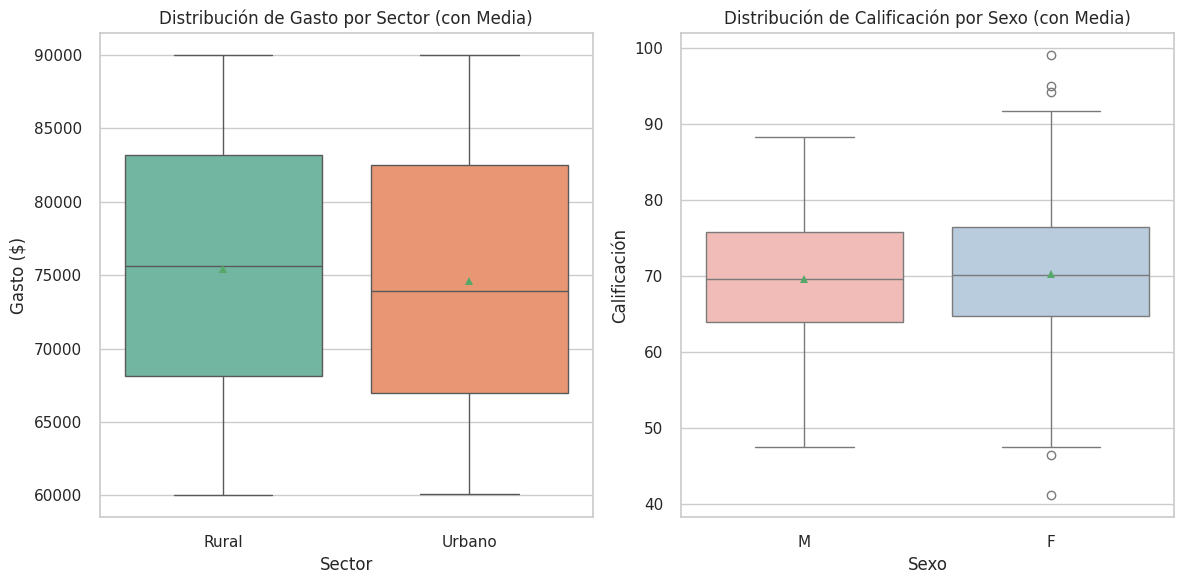

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-load df for robustness if it's not defined
file_id = '1FYphMecW3-PpuAcqcwJKw0ApYSxSegsg'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_excel(url)

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Boxplot: Gasto por Sector
# Esto le dirá a la empresa si los clientes urbanos gastan más que los rurales
plt.subplot(1, 2, 1) # Creamos dos gráficos en una misma fila
sns.boxplot(x='Sector en el que vive', y='Gasto', data=df, palette='Set2', showmeans=True)
plt.title('Distribución de Gasto por Sector (con Media)')
plt.xlabel('Sector')
plt.ylabel('Gasto ($)')

# 3. Boxplot: Calificación por Sexo
# Para ver si el producto premium tiene mejor aceptación en un género específico
plt.subplot(1, 2, 2)
sns.boxplot(x='Sexo', y='Calificación que le daría al producto', data=df, palette='Pastel1', showmeans=True)
plt.title('Distribución de Calificación por Sexo (con Media)')
plt.xlabel('Sexo')
plt.ylabel('Calificación')

plt.tight_layout()
plt.show()

###CONSTRUCCIÓN DEL MÓDELO

In [ ]:
# Eliminar las columnas categóricas originales y definir las características (X) y el objetivo (y).
data_for_model = df.drop(columns=['Sexo', 'Sector en el que vive'])

X = data_for_model.drop(['Precio de compra'], axis=1)
y = data_for_model['Precio de compra']

# Dividimos los datos en conjuntos de entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% Train y 30% Test

### **Modelo de Regresión Lineal**

In [ ]:
#En este segmento de código, se implementa un proceso estándar de modelado
#predictivo mediante regresión lineal. Primero, se instancia el objeto
#LinearRegression(), que representa el modelo lineal que se va a entrenar.
#Posteriormente, se procede al entrenamiento de dicho modelo utilizando el
#conjunto de datos de entrenamiento (X_train como variables predictoras e y_train
#como la variable objetivo), mediante el método .fit(). Finalmente, una vez que el modelo
#ha sido ajustado, se utiliza para generar predicciones sobre el conjunto de datos de prueba
#(X_test), y estos resultados se almacenan en la variable y_pred.""

linear_model = LinearRegression()

#Entrenar el modelo utilizando los datos de entrenamiento
linear_model.fit(X_train, y_train)

# Hacemos las prediciones correspondientes del data set
y_pred = linear_model.predict(X_test)


In [ ]:
# Evaluamos el modelo
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Mostrar coeficientes
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': linear_model.coef_})
print("\nModel Coefficients:")
display(coefficients_df)

R-squared: 0.9196
Mean Absolute Error (MAE): 3209.51
Mean Squared Error (MSE): 13268698.94
Root Mean Squared Error (RMSE): 3642.62

Model Coefficients:


,Feature,Coefficient
0,Edad,-32.309649
1,Número de personas que viven con el encuestado,57.313037
2,Salario que gana,0.021387
3,Gasto,0.008649
4,Calificación que le daría al producto,22.294445


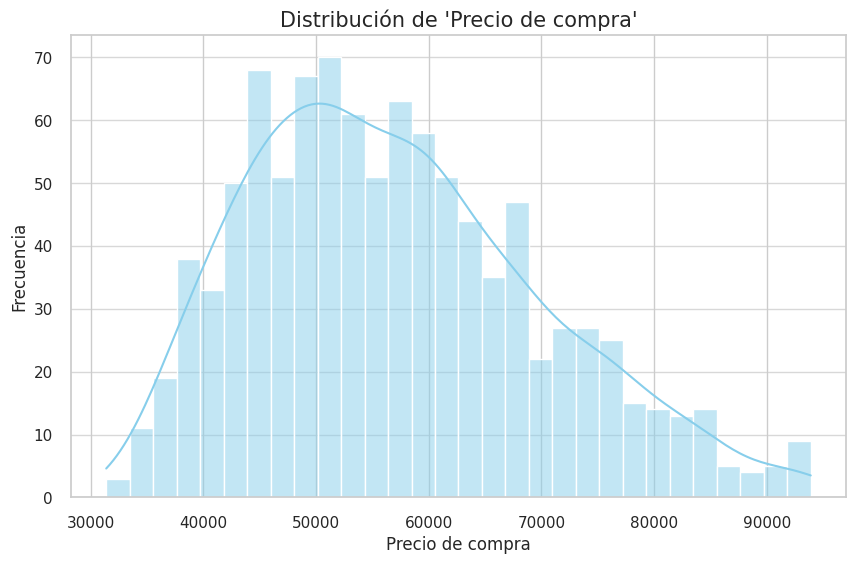

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Precio de compra'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de \'Precio de compra\'', fontsize=15)
plt.xlabel('Precio de compra', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Eliminar las columnas categóricas originales ('Sexo' y 'Sector en el que vive') del DataFrame.
# Esto crea un nuevo DataFrame 'data_for_model_3' que solo contiene columnas numéricas y las codificadas binariamente.
data_for_model_3 = df.drop(columns=['Sexo', 'Sector en el que vive'])

# Definir las características (features) como todas las columnas en 'data_for_model_3' excepto 'Precio de compra'.
features = data_for_model_3.drop(['Precio de compra'], axis=1)

# Definir la variable objetivo (target) como la columna 'Precio de compra'.
target = data_for_model_3['Precio de compra']

In [ ]:
# @title
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42) # 80 - 20%

In [ ]:
# @title
# Mostrar el tamaño de los DataSets Resultantes
print("features_train shape:", features_train.shape)
print("features_test shape:", features_test.shape)
print("target_train shape:", target_train.shape)
print("target_test shape:", target_test.shape)

features_train shape: (800, 5)
features_test shape: (200, 5)
target_train shape: (800,)
target_test shape: (200,)


In [ ]:
# @title
model_simple_lin_reg_3 = LinearRegression()

In [ ]:
# @title
model_simple_lin_reg_3.fit(features_train,target_train)

LinearRegression()

In [ ]:
def predict_kelly_cupcakes_price(Edad, Num_Personas_Hogar, Salario_Gana, Gasto, Calificacion_Producto, Sexo_Binario, Sector_Binario, Segmento):
    """
    Realiza predicciones del 'Precio de compra' de Kelly Cupcakes usando el modelo de Regresión Lineal.
    """
    try:
        # Crear un DataFrame con las columnas correctas para el modelo
        input_data = pd.DataFrame([[Edad, Num_Personas_Hogar, Salario_Gana, Gasto, Calificacion_Producto, Sexo_Binario, Sector_Binario, Segmento]],
                                   columns=['Edad', 'Número de personas que viven con el encuestado', 'Salario que gana', 'Gasto', 'Calificación que le daría al producto', 'Sexo_Binario', 'Sector_Binario', 'Segmento'])

        prediction = model_simple_lin_reg_3.predict(input_data)

        print(f"--- Predicción de Precio de Compra (Modelo Regresión Lineal) ---")
        print(f"Parámetros de entrada: ")
        print(f"  Edad: {Edad}")
        print(f"  Número de personas en el hogar: {Num_Personas_Hogar}")
        print(f"  Salario que gana: {Salario_Gana}")
        print(f"  Gasto: {Gasto}")
        print(f"  Calificación del producto: {Calificacion_Producto:.2f}")
        print(f"  Sexo (0=M, 1=F): {Sexo_Binario}")
        print(f"  Sector (0=Rural, 1=Urbano): {Sector_Binario}")
        print(f"  Segmento: {Segmento}")
        print(f"Precio de compra estimado: ${prediction[0]:.2f}")
    except NameError:
        print("Error: Asegúrate de haber ejecutado las celdas de entrenamiento del modelo de Regresión Lineal primero.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Interfaz interactiva con rangos específicos para cada variable
interact(predict_kelly_cupcakes_price,
         Edad=(17, 45, 1),
         Num_Personas_Hogar=(0, 4, 1),
         Salario_Gana=(300000, 3000000, 10000),
         Gasto=(60000, 90000, 100),
         Calificacion_Producto=(40.0, 100.0, 0.5),
         Sexo_Binario=[0, 1],
         Sector_Binario=[0, 1],
         Segmento=[0, 1, 2]);

interactive(children=(IntSlider(value=31, description='Edad', max=45, min=17), IntSlider(value=2, description=…

In [ ]:
# @title
target_train_pred = model_simple_lin_reg_3.predict(features_train)
target_test_pred = model_simple_lin_reg_3.predict(features_test)


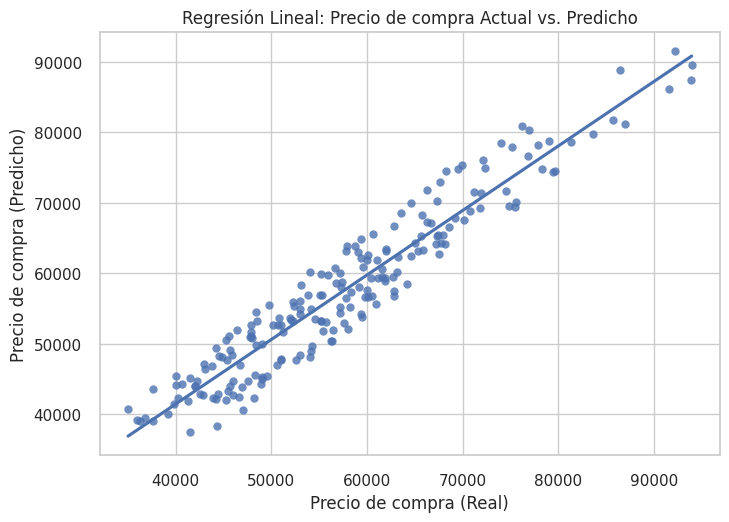

In [ ]:
# @title
# Graficamos los valores reales en el set de pruebas vs los valores que el módelo predijo
sns.regplot(x=target_test, y=target_test_pred, ci=None)
plt.title('Regresión Lineal: Precio de compra Actual vs. Predicho')
plt.xlabel('Precio de compra (Real)')
plt.ylabel('Precio de compra (Predicho)')
plt.show()


In [ ]:
from sklearn import metrics

# 1. Definición de variables (basado en la correlación más fuerte detectada)
# X es la variable predictora (Salario) y 'y' es lo que queremos predecir (Precio de compra)
X = df[['Salario que gana']]
y = df['Precio de compra']

# 2. División de los datos en Entrenamiento (Train) y Prueba (Test)
# Esto permite validar si el modelo realmente aprendió o solo memorizó
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación y entrenamiento del modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 4. Realización de predicciones y evaluación
y_pred = modelo_lineal.predict(X_test)

# Métricas finales
r2 = metrics.r2_score(y_test, y_pred)
intercepto = modelo_lineal.intercept_
pendiente = modelo_lineal.coef_[0]

print(f"--- Resumen del Modelo Predictivo ---")
print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"Intercepto (b0): {intercepto:.2f}")
print(f"Pendiente (b1): {pendiente:.4f}")

--- Resumen del Modelo Predictivo ---
Coeficiente de determinación (R²): 0.9120
Intercepto (b0): 27913.85
Pendiente (b1): 0.0213


regresion 2

In [ ]:
# @title
# Construcción o definición del Modelo

from sklearn.pipeline import Pipeline

model_poly_d2 = Pipeline([ # d2 = grado 2
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

In [ ]:
# Entrenamiento del Modelo Polinomial con los datos de Kelly Cupcakes
model_poly_d2.fit(features_train, target_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('linear', LinearRegression())])

In [ ]:
# Realizamos predicciones con el modelo polinomial para los datos de Kelly Cupcakes
y_train_poly_pred = model_poly_d2.predict(features_train)
y_test_poly_pred = model_poly_d2.predict(features_test)

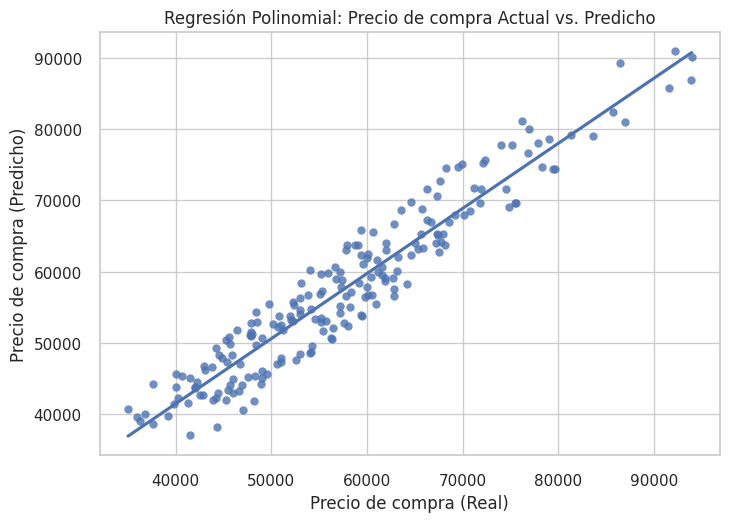

In [ ]:
# Graficamos los valores reales en el set de pruebas vs los valores que el modelo polinomial predijo
sns.regplot(x=target_test, y=y_test_poly_pred, ci=None)
plt.title('Regresión Polinomial: Precio de compra Actual vs. Predicho')
plt.xlabel('Precio de compra (Real)')
plt.ylabel('Precio de compra (Predicho)')
plt.show()

In [ ]:


# 1. Preparar las variables del modelo
# X: Salario (predictora) | y: Precio (objetivo)
X = df[['Salario que gana']]
y = df['Precio de compra']

# 2. Entrenar el modelo matemático
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Obtener los cálculos exactos
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# 4. Crear la tabla resumen como en el ejemplo
datos_tabla = {
    "Métrica": [
        "Pendiente (b1)",
        "Intercepto (b0)",
        "R-cuadrado (R2)",
        "Error Cuadrático Medio (MSE)"
    ],
    "Valor del Proyecto": [
        f"{pendiente:.4f}",
        f"{intercepto:.2f}",
        f"{r2:.4f}",
        f"{mse:.2f}"
    ],
    "Interpretación Académica": [
        f"Por cada peso extra de salario, el precio aumenta {pendiente:.4f} unidades.",
        "Valor base del precio cuando el salario es cero.",
        f"El modelo explica el {r2*100:.2f}% de los datos (ajuste muy alto).",
        "Magnitud del error promedio en las predicciones."
    ]
}

# 5. Mostrar la tabla final
tabla_final = pd.DataFrame(datos_tabla)
display(tabla_final)

,Métrica,Valor del Proyecto,Interpretación Académica
0,Pendiente (b1),0.0213,"Por cada peso extra de salario, el precio aume..."
1,Intercepto (b0),27916.51,Valor base del precio cuando el salario es cero.
2,R-cuadrado (R2),0.9243,El modelo explica el 92.43% de los datos (ajus...
3,Error Cuadrático Medio (MSE),12654340.78,Magnitud del error promedio en las predicciones.


experimento 3

In [ ]:
# @title
# Selección o construcción del modelo (algoritmo)
from sklearn.linear_model import Ridge
model_ridge = Ridge()

In [ ]:
# Entrenamiento del Modelo
model_ridge.fit(features_train, target_train)

Ridge()

In [ ]:
# Realizamos predicciones con el modelo Ridge para los datos de Kelly Cupcakes
y_train_ridge_pred = model_ridge.predict(features_train)
y_test_ridge_pred = model_ridge.predict(features_test)

In [ ]:
def train_val(y_train, y_train_pred, y_test, y_test_pred, model_name):
    scores = {
        'Model': model_name,
        'R2 Train': r2_score(y_train, y_train_pred),
        'MAE Train': mean_absolute_error(y_train, y_train_pred),
        'MSE Train': mean_squared_error(y_train, y_train_pred),
        'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'R2 Test': r2_score(y_test, y_test_pred),
        'MAE Test': mean_absolute_error(y_test, y_test_pred),
        'MSE Test': mean_squared_error(y_test, y_test_pred),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred))
    }
    return pd.DataFrame([scores])

# Evaluamos el modelo Ridge utilizando la función train_val
ridge_score = train_val(target_train, y_train_ridge_pred, target_test, y_test_ridge_pred, 'Ridge Regression')
display(ridge_score)

,Model,R2 Train,MAE Train,MSE Train,RMSE Train,R2 Test,MAE Test,MSE Test,RMSE Test
0,Ridge Regression,0.927416,3037.138937,1.240017e+07,3521.387259,0.913269,3207.492615,1.318132e+07,3630.608769


In [ ]:
# Mostrar coeficientes del modelo Ridge
ridge_coefficients_df = pd.DataFrame({'Feature': features.columns, 'Coefficient': model_ridge.coef_})
print("\nModel Coefficients (Ridge Regression):")
display(ridge_coefficients_df)


Model Coefficients (Ridge Regression):


,Feature,Coefficient
0,Edad,-41.732303
1,Número de personas que viven con el encuestado,132.108360
2,Salario que gana,0.021268
3,Gasto,0.004054
4,Calificación que le daría al producto,19.520322


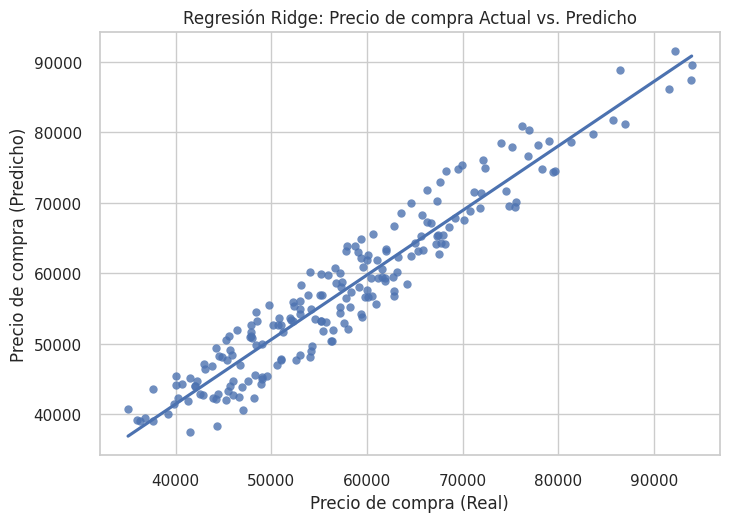

In [ ]:
# Graficamos los valores reales en el set de pruebas vs los valores que el modelo Ridge predijo
sns.regplot(x=target_test, y=y_test_ridge_pred, ci=None)
plt.title('Regresión Ridge: Precio de compra Actual vs. Predicho')
plt.xlabel('Precio de compra (Real)')
plt.ylabel('Precio de compra (Predicho)')
plt.show()